Checking for missing values and outliers...


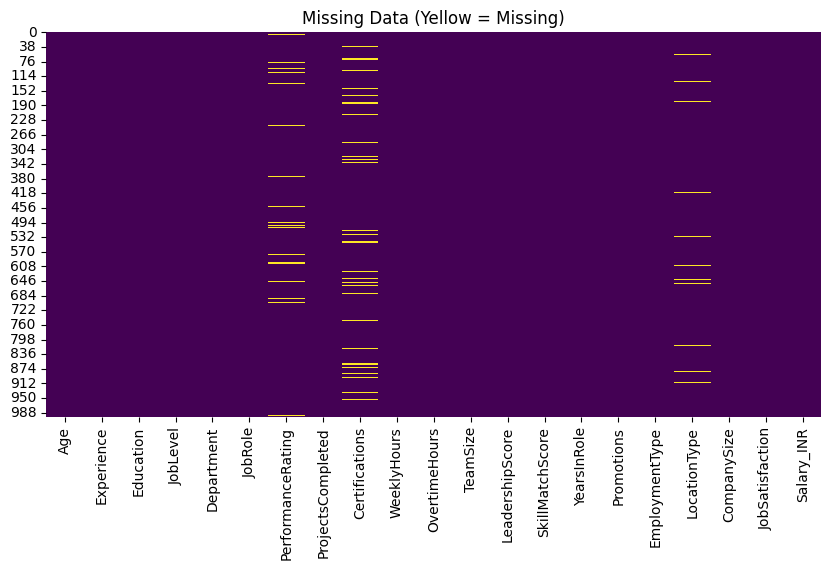

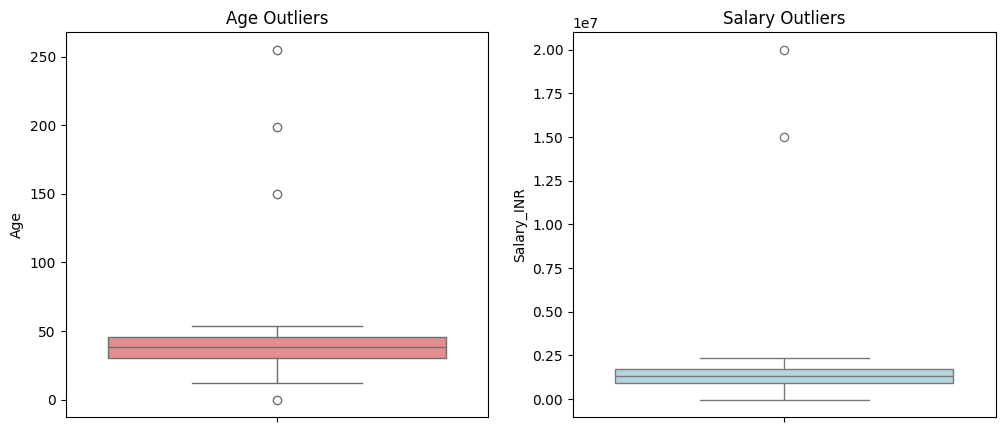

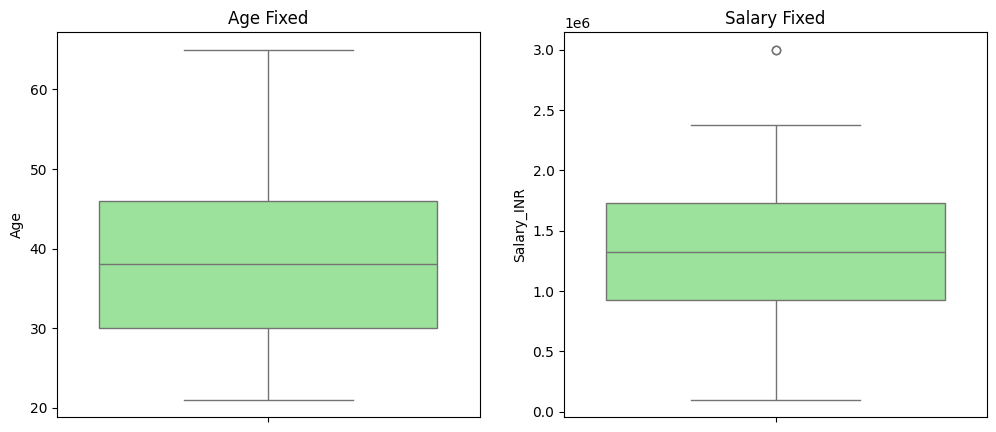

Done! Saved as cleaned_employee_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# load the messy dataset the teacher gave us
df = pd.read_csv("employee_salary_dataset2.csv")

# --- 1. EDA (Seeing how bad the data is) ---
print("Checking for missing values and outliers...")

# heat map to visualize missing data
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data (Yellow = Missing)")
plt.show() 

# boxplots to spot the outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Age'], ax=axes[0], color='lightcoral').set_title('Age Outliers')
sns.boxplot(y=df['Salary_INR'], ax=axes[1], color='lightblue').set_title('Salary Outliers')
plt.show()


# Overwriting the columns directly to avoid the Copy-on-Write warning
df['PerformanceRating'] = df['PerformanceRating'].fillna(df['PerformanceRating'].median())
df['Certifications'] = df['Certifications'].fillna(df['Certifications'].median())

# using mode (most common value) for text columns
df['LocationType'] = df['LocationType'].fillna(df['LocationType'].mode()[0])

# --- 3. Fixing Outliers (Capping) ---
df['Age'] = np.clip(df['Age'], 21, 65)  
df['Experience'] = np.clip(df['Experience'], 0, 45) 
df['WeeklyHours'] = np.clip(df['WeeklyHours'], 20, 80) 
df['Salary_INR'] = np.clip(df['Salary_INR'], 100000, 3000000) # cap at 30 lakhs

# quick check to prove the outliers are actually gone
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Age'], ax=axes[0], color='lightgreen').set_title('Age Fixed')
sns.boxplot(y=df['Salary_INR'], ax=axes[1], color='lightgreen').set_title('Salary Fixed')
plt.show()

# --- 4. Prepping for ML ---

cat_cols = ['Education', 'JobLevel', 'Department', 'JobRole', 
            'EmploymentType', 'LocationType', 'CompanySize']

le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c].astype(str)) # converting to string first just in case

num_cols = ['Age', 'Experience', 'PerformanceRating', 'ProjectsCompleted', 
            'Certifications', 'WeeklyHours', 'OvertimeHours', 'TeamSize', 
            'LeadershipScore', 'SkillMatchScore', 'YearsInRole', 'Promotions', 
            'JobSatisfaction']

sc = StandardScaler()
df[num_cols] = np.round(sc.fit_transform(df[num_cols]), 4)

# --- 5. Save the final file ---
out_file = "cleaned_employee_dataset.csv"
df.to_csv(out_file, index=False)
print("Done! Saved as", out_file)